# Artificial Bee Colony for Physical OPM Sensor Selection



The goal is to identify a compact and stable set of physical QSpin OPM sensors for classifying:

- `cue_Left`
- `cue_Right`

Each physical sensor is one selectable unit. Its available X, Y and Z channels remain grouped.



In [1]:
%pip install -q --upgrade "mne==1.9.0" "scikit-learn>=1.4,<1.7" joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 53.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Restart the Kaggle session only if requested, then continue from the imports cell.

In [2]:
from __future__ import annotations

import json
import re
import shutil
import sys
import warnings
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("MNE:", mne.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

try:
    import sklearn
    print("scikit-learn:", sklearn.__version__)
except Exception:
    pass

try:
    import psutil
    memory = psutil.virtual_memory()
    print(
        f"Available RAM: {memory.available / 1024**3:.2f} GiB / "
        f"{memory.total / 1024**3:.2f} GiB"
    )
except Exception:
    print("psutil unavailable; RAM report skipped.")

Python: 3.12.13
MNE: 1.9.0
NumPy: 2.4.6
Pandas: 2.3.3
scikit-learn: 1.6.1
Available RAM: 30.23 GiB / 31.35 GiB


In [ ]:
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/flux_abc")
EXTRACT_ROOT = WORK_ROOT / "extracted_epochs"
FIGURE_ROOT = WORK_ROOT / "figures"
REPORT_ROOT = WORK_ROOT / "reports"
MODEL_ROOT = WORK_ROOT / "models"

for directory in (
    WORK_ROOT,
    EXTRACT_ROOT,
    FIGURE_ROOT,
    REPORT_ROOT,
    MODEL_ROOT,
):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT = "01"
SESSION = "01"
TASK = "SpAtt"
RUN = "01"

EPOCHS_FILE_OVERRIDE = None

# First workflow validation: True.
# Stable final analysis: False.
QUICK_MODE = True
QUICK_TRIALS_PER_CONDITION = 40

FILTER_L_FREQ_HZ = 1.0
FILTER_H_FREQ_HZ = 30.0
FILTER_ORDER = 4
RESAMPLE_HZ = 100.0

FEATURE_TMIN_S = 0.00
FEATURE_TMAX_S = 0.80
N_TIME_WINDOWS = 8
FEATURE_STATS = ("mean", "std", "rms")

REQUIRE_COMPLETE_XYZ = False


# Change to 30 or 35 for the reduced-headset analysis.
TARGET_SENSOR_COUNT = 10

# ABC population and stopping parameters.
QUICK_FOOD_SOURCES = 6
QUICK_CYCLES = 8
QUICK_RUNS = 2
QUICK_ABANDONMENT_LIMIT = 4

FINAL_FOOD_SOURCES = 20
FINAL_CYCLES = 40
FINAL_RUNS = 10
FINAL_ABANDONMENT_LIMIT = 10

# Fraction of initial solutions sampled using the univariate heuristic.
HEURISTIC_INITIALISATION_FRACTION = 0.70
HEURISTIC_POWER = 2.0

REDUNDANCY_WEIGHT = 0.02

SVM_C = 1.0
SVM_CLASS_WEIGHT = None

RANDOM_STATE = 42
QUICK_INNER_SPLITS = 3
FINAL_INNER_SPLITS = 5

RUN_NESTED_CV = True
QUICK_OUTER_SPLITS = 3
FINAL_OUTER_SPLITS = 5

INNER_N_JOBS = 1
OUTER_N_JOBS = 1

CONSENSUS_CV_SPLITS = 5
CONSENSUS_CV_REPEATS = 5

RANDOM_BASELINE_REPEATS = 30

RUN_SENSOR_COUNT_CURVE = False
SENSOR_COUNTS_TO_TEST = [5, 10, 15, 20, 25, 30, 35]
COUNT_CURVE_FOOD_SOURCES = 8
COUNT_CURVE_CYCLES = 10

RUN_TIME_RESOLVED_DECODING = True
TIME_DECODING_TMIN_S = -0.10
TIME_DECODING_TMAX_S = 1.00
TIME_DECODING_CV_SPLITS = 5

TOP_SENSORS_FOR_ENERGY_PLOTS = 5

ABC_FOOD_SOURCES = (
    QUICK_FOOD_SOURCES
    if QUICK_MODE
    else FINAL_FOOD_SOURCES
)
ABC_CYCLES = (
    QUICK_CYCLES
    if QUICK_MODE
    else FINAL_CYCLES
)
ABC_RUNS = (
    QUICK_RUNS
    if QUICK_MODE
    else FINAL_RUNS
)
ABC_ABANDONMENT_LIMIT = (
    QUICK_ABANDONMENT_LIMIT
    if QUICK_MODE
    else FINAL_ABANDONMENT_LIMIT
)
INNER_SPLITS = (
    QUICK_INNER_SPLITS
    if QUICK_MODE
    else FINAL_INNER_SPLITS
)
OUTER_SPLITS = (
    QUICK_OUTER_SPLITS
    if QUICK_MODE
    else FINAL_OUTER_SPLITS
)

print("Quick mode:", QUICK_MODE)
print("Target sensors:", TARGET_SENSOR_COUNT)
print(
    "ABC food sources / cycles / runs / limit:",
    ABC_FOOD_SOURCES,
    ABC_CYCLES,
    ABC_RUNS,
    ABC_ABANDONMENT_LIMIT,
)

Quick mode: True
Target sensors: 10
ABC food sources / cycles / runs / limit: 6 8 2 4


In [4]:
def is_probable_first_split(path):
    name = path.name.casefold()

    if "split-" not in name and not re.search(r"-\d+\.fif$", name):
        return True

    return bool(
        re.search(
            r"(?:_|-)split-0*1(?:_|-)",
            name,
        )
    )


def resolve_override(value, label):
    if value is None:
        return None

    path = Path(value)

    if not path.exists():
        raise FileNotFoundError(
            f"{label} override does not exist: {path}"
        )

    return path


override = resolve_override(
    EPOCHS_FILE_OVERRIDE,
    "Epochs file",
)

if override is not None:
    epoch_candidates = [override]

else:
    epoch_candidates = [
        path
        for path in INPUT_ROOT.rglob("*.fif")
        if (
            path.name.casefold().endswith("_epo.fif")
            or "_epo-" in path.name.casefold()
        )
        and is_probable_first_split(path)
    ]

    if not epoch_candidates:
        archives = [
            path
            for path in INPUT_ROOT.rglob("*.zip")
            if (
                "epoch" in path.name.casefold()
                or "condition" in path.name.casefold()
            )
            and "figure" not in path.name.casefold()
            and "report" not in path.name.casefold()
        ]

        for index, archive_path in enumerate(archives):
            destination = (
                EXTRACT_ROOT
                / f"archive_{index:02d}_{archive_path.stem}"
            )
            destination.mkdir(
                parents=True,
                exist_ok=True,
            )

            print("Extracting:", archive_path)

            with zipfile.ZipFile(archive_path, "r") as archive:
                archive.extractall(destination)

        epoch_candidates = [
            path
            for path in EXTRACT_ROOT.rglob("*.fif")
            if (
                path.name.casefold().endswith("_epo.fif")
                or "_epo-" in path.name.casefold()
            )
            and is_probable_first_split(path)
        ]

    epoch_candidates = sorted(
        epoch_candidates,
        key=lambda path: (
            int(
                "quick" not in path.name.casefold()
                and "test" not in path.name.casefold()
            ),
            int("desc-cue" in path.name.casefold()),
            int("analysis" in str(path).casefold()),
            str(path),
        ),
        reverse=True,
    )

if not epoch_candidates:
    raise FileNotFoundError(
        "No condition-specific epoch FIF was found."
    )

print("Epoch candidates:")

for index, path in enumerate(epoch_candidates[:20]):
    print(f"  [{index}] {path}")

EPOCHS_FILE = epoch_candidates[0]

print("\nSelected:", EPOCHS_FILE)

Epoch candidates:
  [0] /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif

Selected: /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


In [5]:
epochs = mne.read_epochs(
    EPOCHS_FILE,
    proj=False,
    preload=True,
    verbose=True,
)

print(epochs)
print("Conditions:", epochs.event_id)
print("Channels:", len(epochs.ch_names))
print("Sampling frequency:", epochs.info["sfreq"])
print("Epoch interval:", (epochs.tmin, epochs.tmax))
print("Bad channels:", epochs.info.get("bads", []))

condition_count_df = pd.DataFrame(
    [
        {
            "condition": condition,
            "epochs": len(epochs[condition]),
        }
        for condition in epochs.event_id
    ]
).sort_values("condition")

display(condition_count_df)

condition_count_df.to_csv(
    REPORT_ROOT / "input_condition_counts.csv",
    index=False,
)

Reading /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 180) active
        HFC: l=1 m=0 (1 x 180) active
        HFC: l=1 m=1 (1 x 180) active
        HFC: l=2 m=-2 (1 x 180) active
        HFC: l=2 m=-1 (1 x 180) active
        HFC: l=2 m=0 (1 x 180) active
        HFC: l=2 m=1 (1 x 180) active
        HFC: l=2 m=2 (1 x 180) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
219 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)
<EpochsFIF | 219 events (all good), -0.749 – 2 s (baseline off), ~719.1 MiB, data loaded,
 'cue_Left': 113
 'cue_Right': 106>
Conditions: {'cue_Left': 5, 'cue_Right': 6}
Channels: 207
Sampling frequency: 750.0
Epoch interval: (np.float64(-0

,condition,epochs
0,cue_Left,113
1,cue_Right,106


In [6]:
def normalise_condition_name(name):
    return "_".join(
        re.findall(
            r"[a-z0-9]+",
            str(name).casefold(),
        )
    )


def identify_condition(event_id, direction):
    matches = []

    for condition_name in event_id:
        normalised = normalise_condition_name(
            condition_name
        )
        tokens = set(normalised.split("_"))

        if (
            ("cue" in tokens or normalised.startswith("cue"))
            and direction.casefold() in tokens
        ):
            matches.append(condition_name)

    if len(matches) != 1:
        raise ValueError(
            f"Expected one cue-{direction} condition, "
            f"found {matches}. Available: {event_id}"
        )

    return matches[0]


left_condition = identify_condition(
    epochs.event_id,
    "left",
)
right_condition = identify_condition(
    epochs.event_id,
    "right",
)

print(
    "Cue-left:",
    left_condition,
    len(epochs[left_condition]),
)
print(
    "Cue-right:",
    right_condition,
    len(epochs[right_condition]),
)

Cue-left: cue_Left 113
Cue-right: cue_Right 106


In [7]:
_AXIS_PATTERN = re.compile(
    r"(?:^|[\s_-])([XYZ])$",
    flags=re.IGNORECASE,
)


def infer_axis(channel_name):
    match = _AXIS_PATTERN.search(
        channel_name.strip()
    )

    if match:
        return match.group(1).upper()

    if (
        channel_name
        and channel_name.strip()[-1].upper()
        in {"X", "Y", "Z"}
    ):
        return channel_name.strip()[-1].upper()

    return None


def physical_sensor_name(channel_name):
    name = re.sub(
        r"(?:[\s_-]+)[XYZ]$",
        "",
        channel_name.strip(),
        flags=re.IGNORECASE,
    )

    return re.sub(
        r"\s+",
        " ",
        name,
    ).strip()


good_mag_names = [
    name
    for name, channel_type in zip(
        epochs.ch_names,
        epochs.get_channel_types(),
    )
    if channel_type == "mag"
    and name not in epochs.info.get("bads", [])
]

sensor_to_channels = defaultdict(list)

for channel_name in good_mag_names:
    axis = infer_axis(channel_name)

    if axis is not None:
        sensor_to_channels[
            physical_sensor_name(channel_name)
        ].append(channel_name)

sensor_rows = []

for sensor_name, channels in sorted(
    sensor_to_channels.items()
):
    axes = sorted(
        axis
        for axis in (
            infer_axis(channel)
            for channel in channels
        )
        if axis is not None
    )

    sensor_rows.append(
        {
            "physical_sensor": sensor_name,
            "n_channels": len(channels),
            "axes": ",".join(axes),
            "complete_xyz": (
                set(axes) == {"X", "Y", "Z"}
            ),
            "channels": "|".join(channels),
        }
    )

sensor_inventory_df = pd.DataFrame(
    sensor_rows
)

if REQUIRE_COMPLETE_XYZ:
    retained_sensor_names = (
        sensor_inventory_df.loc[
            sensor_inventory_df["complete_xyz"],
            "physical_sensor",
        ].tolist()
    )
else:
    retained_sensor_names = (
        sensor_inventory_df[
            "physical_sensor"
        ].tolist()
    )

sensor_inventory_df[
    "retained_for_abc"
] = sensor_inventory_df[
    "physical_sensor"
].isin(retained_sensor_names)

display(sensor_inventory_df)

sensor_inventory_df.to_csv(
    REPORT_ROOT / "physical_sensor_inventory.csv",
    index=False,
)

print("Good magnetometer channels:", len(good_mag_names))
print("Physical sensors discovered:", len(sensor_inventory_df))
print("Physical sensors retained:", len(retained_sensor_names))

if TARGET_SENSOR_COUNT > len(retained_sensor_names):
    raise ValueError(
        "TARGET_SENSOR_COUNT exceeds the available sensor count."
    )

,physical_sensor,n_channels,axes,complete_xyz,channels,retained_for_abc
0,C1 A7,3,"X,Y,Z",True,C1 A7 Z|C1 A7 Y|C1 A7 X,True
1,C2 B5,3,"X,Y,Z",True,C2 B5 Z|C2 B5 Y|C2 B5 X,True
2,C3 C2,3,"X,Y,Z",True,C3 C2 Z|C3 C2 Y|C3 C2 X,True
3,C4 D7,3,"X,Y,Z",True,C4 D7 Z|C4 D7 Y|C4 D7 X,True
4,C5 C1,3,"X,Y,Z",True,C5 C1 Z|C5 C1 Y|C5 C1 X,True
...,...,...,...,...,...,...
57,T5 C5,1,X,False,T5 C5 X,True
58,T6 D6,3,"X,Y,Z",True,T6 D6 Z|T6 D6 Y|T6 D6 X,True
59,T7 C8,3,"X,Y,Z",True,T7 C8 Z|T7 C8 Y|T7 C8 X,True
60,T8 D2,3,"X,Y,Z",True,T8 D2 Z|T8 D2 Y|T8 D2 X,True


Good magnetometer channels: 180
Physical sensors discovered: 62
Physical sensors retained: 62


In [8]:
selected_channel_names = []

for sensor_name in retained_sensor_names:
    selected_channel_names.extend(
        sensor_to_channels[sensor_name]
    )

epochs_signal = epochs.copy().pick(
    selected_channel_names
)


def select_evenly_spaced(
    condition_epochs,
    requested_count,
):
    if requested_count >= len(condition_epochs):
        return condition_epochs

    indices = np.unique(
        np.linspace(
            0,
            len(condition_epochs) - 1,
            requested_count,
        ).round().astype(int)
    )

    return condition_epochs[indices]


if QUICK_MODE:
    left_epochs = select_evenly_spaced(
        epochs_signal[left_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
    right_epochs = select_evenly_spaced(
        epochs_signal[right_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
else:
    left_epochs = epochs_signal[left_condition]
    right_epochs = epochs_signal[right_condition]

epochs_signal = mne.concatenate_epochs(
    [left_epochs, right_epochs],
    add_offset=True,
    on_mismatch="raise",
    verbose=False,
)

y = np.concatenate(
    [
        np.zeros(
            len(left_epochs),
            dtype=int,
        ),
        np.ones(
            len(right_epochs),
            dtype=int,
        ),
    ]
)

iir_params = {
    "order": FILTER_ORDER,
    "ftype": "butter",
    "output": "sos",
}

epochs_signal.filter(
    l_freq=FILTER_L_FREQ_HZ,
    h_freq=FILTER_H_FREQ_HZ,
    picks="mag",
    method="iir",
    iir_params=iir_params,
    phase="zero",
    verbose=True,
)

epochs_signal.resample(
    RESAMPLE_HZ,
    npad="auto",
    verbose=True,
)

if (
    FEATURE_TMIN_S < epochs_signal.tmin
    or FEATURE_TMAX_S > epochs_signal.tmax
):
    raise ValueError(
        "The feature interval lies outside the epoch."
    )

X_signal = epochs_signal.get_data(
    copy=True
)
signal_times = epochs_signal.times.copy()
signal_channel_names = list(
    epochs_signal.ch_names
)

print("Signal matrix:", X_signal.shape)
print("Labels:", np.bincount(y, minlength=2))

Setting up band-pass filter from 1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 30.00 Hz: -6.02, -6.02 dB

Signal matrix: (80, 180, 275)
Labels: [40 40]


In [9]:
window_edges = np.linspace(
    FEATURE_TMIN_S,
    FEATURE_TMAX_S,
    N_TIME_WINDOWS + 1,
)

channel_index = {
    channel_name: index
    for index, channel_name
    in enumerate(signal_channel_names)
}

feature_blocks = []
feature_names = []
sensor_feature_columns = {}
column_start = 0

for sensor_name in retained_sensor_names:
    sensor_channels = [
        channel
        for channel
        in sensor_to_channels[sensor_name]
        if channel in channel_index
    ]

    sensor_indices = [
        channel_index[channel]
        for channel in sensor_channels
    ]

    sensor_data = X_signal[
        :,
        sensor_indices,
        :,
    ]

    sensor_features = []
    sensor_feature_names = []

    for window_index in range(
        N_TIME_WINDOWS
    ):
        tmin = window_edges[
            window_index
        ]
        tmax = window_edges[
            window_index + 1
        ]

        if (
            window_index
            == N_TIME_WINDOWS - 1
        ):
            time_mask = (
                (signal_times >= tmin)
                & (signal_times <= tmax)
            )
        else:
            time_mask = (
                (signal_times >= tmin)
                & (signal_times < tmax)
            )

        if not np.any(time_mask):
            raise ValueError(
                f"No samples in {tmin}–{tmax} s."
            )

        window_data = sensor_data[
            :,
            :,
            time_mask,
        ]

        for local_index, channel_name in enumerate(
            sensor_channels
        ):
            axis = infer_axis(channel_name)
            axis_data = window_data[
                :,
                local_index,
                :,
            ]

            if "mean" in FEATURE_STATS:
                sensor_features.append(
                    np.mean(
                        axis_data,
                        axis=1,
                    )
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|"
                    f"w{window_index}|mean"
                )

            if "std" in FEATURE_STATS:
                sensor_features.append(
                    np.std(
                        axis_data,
                        axis=1,
                    )
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|"
                    f"w{window_index}|std"
                )

            if "rms" in FEATURE_STATS:
                sensor_features.append(
                    np.sqrt(
                        np.mean(
                            axis_data**2,
                            axis=1,
                        )
                    )
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|"
                    f"w{window_index}|rms"
                )

        pooled_rms = np.sqrt(
            np.mean(
                window_data**2,
                axis=(1, 2),
            )
        )

        sensor_features.append(
            pooled_rms
        )
        sensor_feature_names.append(
            f"{sensor_name}|pooled|"
            f"w{window_index}|rms"
        )

    sensor_block = np.column_stack(
        sensor_features
    )

    feature_blocks.append(
        sensor_block
    )
    feature_names.extend(
        sensor_feature_names
    )

    column_stop = (
        column_start
        + sensor_block.shape[1]
    )

    sensor_feature_columns[
        sensor_name
    ] = np.arange(
        column_start,
        column_stop,
        dtype=int,
    )

    column_start = column_stop

X_features = np.concatenate(
    feature_blocks,
    axis=1,
)

pd.DataFrame(
    {
        "feature_index": np.arange(
            len(feature_names)
        ),
        "feature_name": feature_names,
    }
).to_csv(
    REPORT_ROOT / "feature_metadata.csv",
    index=False,
)

print("Feature matrix:", X_features.shape)

Feature matrix: (80, 4816)


In [10]:
def make_classifier():
    return make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=SVM_C,
            class_weight=SVM_CLASS_WEIGHT,
        ),
    )


def subset_columns(
    sensor_subset,
    sensor_columns,
):
    columns = np.concatenate(
        [
            sensor_columns[
                sensor_name
            ]
            for sensor_name
            in sensor_subset
        ]
    )

    return np.asarray(
        sorted(
            columns.tolist()
        ),
        dtype=int,
    )


def cv_auc_for_subset(
    X,
    y_values,
    sensor_subset,
    sensor_columns,
    cv_splits,
):
    columns = subset_columns(
        sensor_subset,
        sensor_columns,
    )

    scores = cross_val_score(
        make_classifier(),
        X[:, columns],
        y_values,
        cv=cv_splits,
        scoring="roc_auc",
        n_jobs=INNER_N_JOBS,
    )

    return (
        float(np.mean(scores)),
        float(np.std(scores)),
    )

In [11]:
def compute_sensor_heuristics(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    n_splits,
    seed,
):
    effective_splits = min(
        n_splits,
        int(
            np.min(
                np.bincount(
                    y_values
                )
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(
        cv.split(
            X,
            y_values,
        )
    )

    rows = []

    for sensor_name in sensor_names:
        mean_auc, std_auc = (
            cv_auc_for_subset(
                X,
                y_values,
                (sensor_name,),
                sensor_columns,
                cv_splits,
            )
        )

        rows.append(
            {
                "physical_sensor": sensor_name,
                "univariate_mean_auc": mean_auc,
                "univariate_std_auc": std_auc,
            }
        )

    heuristic_df = pd.DataFrame(
        rows
    )

    raw = np.maximum(
        heuristic_df[
            "univariate_mean_auc"
        ].to_numpy() - 0.5,
        0.0,
    )

    heuristic = raw + 0.01
    heuristic = (
        heuristic
        / np.sum(heuristic)
    )

    heuristic_df[
        "abc_initialisation_probability"
    ] = heuristic

    return heuristic, heuristic_df


full_heuristic, univariate_df = (
    compute_sensor_heuristics(
        X_features,
        y,
        retained_sensor_names,
        sensor_feature_columns,
        INNER_SPLITS,
        RANDOM_STATE,
    )
)

univariate_df = (
    univariate_df.sort_values(
        "univariate_mean_auc",
        ascending=False,
    ).reset_index(
        drop=True
    )
)

display(
    univariate_df.head(20)
)

univariate_df.to_csv(
    REPORT_ROOT
    / "univariate_sensor_heuristics.csv",
    index=False,
)

,physical_sensor,univariate_mean_auc,univariate_std_auc,abc_initialisation_probability
0,O2 H3,0.747112,0.054550,0.065825
1,Fpz A2,0.671175,0.153205,0.046384
2,T3 C4,0.656805,0.053997,0.042705
3,F9 A4,0.650465,0.053803,0.041082
4,F8 B1,0.645393,0.002263,0.039783
5,F10 B3,0.632291,0.062810,0.036429
6,Fz A5,0.631586,0.124954,0.036248
7,T13 G8,0.628487,0.055753,0.035455
8,P7 E7,0.615526,0.092059,0.032137
9,O1 E5,0.609890,0.085944,0.030694


In [12]:
def compute_sensor_redundancy(
    X,
    sensor_names,
    sensor_columns,
):
    summaries = []

    for sensor_name in sensor_names:
        block = X[
            :,
            sensor_columns[
                sensor_name
            ],
        ]

        block_mean = np.mean(
            block,
            axis=0,
            keepdims=True,
        )

        block_std = np.std(
            block,
            axis=0,
            keepdims=True,
        )

        block_std = np.where(
            block_std > 0,
            block_std,
            1.0,
        )

        standardised = (
            block - block_mean
        ) / block_std

        summaries.append(
            np.mean(
                np.abs(
                    standardised
                ),
                axis=1,
            )
        )

    summary_matrix = np.column_stack(
        summaries
    )

    redundancy = np.abs(
        np.corrcoef(
            summary_matrix,
            rowvar=False,
        )
    )

    redundancy = np.nan_to_num(
        redundancy,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    np.fill_diagonal(
        redundancy,
        0.0,
    )

    return redundancy


full_redundancy = (
    compute_sensor_redundancy(
        X_features,
        retained_sensor_names,
        sensor_feature_columns,
    )
)

pd.DataFrame(
    full_redundancy,
    index=retained_sensor_names,
    columns=retained_sensor_names,
).to_csv(
    REPORT_ROOT
    / "sensor_redundancy_matrix.csv"
)

print(
    "Redundancy matrix:",
    full_redundancy.shape,
)

Redundancy matrix: (62, 62)


In [13]:
@dataclass
class ABCResult:
    best_subset: tuple
    best_fitness: float
    best_auc: float
    best_redundancy: float
    convergence: list
    evaluated_subsets: int
    scout_events: int


def subset_redundancy(
    subset_indices,
    redundancy_matrix,
):
    if len(subset_indices) < 2:
        return 0.0

    submatrix = redundancy_matrix[
        np.ix_(
            subset_indices,
            subset_indices,
        )
    ]

    upper = submatrix[
        np.triu_indices(
            len(subset_indices),
            k=1,
        )
    ]

    return float(
        np.mean(upper)
    )


def weighted_initial_subset(
    n_sensors,
    subset_size,
    heuristic,
    rng,
):
    use_heuristic = (
        rng.random()
        < HEURISTIC_INITIALISATION_FRACTION
    )

    if use_heuristic:
        probabilities = np.power(
            heuristic,
            HEURISTIC_POWER,
        )

        probabilities = (
            probabilities
            / np.sum(
                probabilities
            )
        )
    else:
        probabilities = None

    return tuple(
        sorted(
            rng.choice(
                np.arange(
                    n_sensors
                ),
                size=subset_size,
                replace=False,
                p=probabilities,
            ).tolist()
        )
    )


def one_swap_neighbour(
    subset_indices,
    n_sensors,
    rng,
):
    selected = list(
        subset_indices
    )

    unselected = list(
        set(
            range(n_sensors)
        )
        - set(selected)
    )

    remove_sensor = int(
        rng.choice(selected)
    )
    add_sensor = int(
        rng.choice(unselected)
    )

    selected.remove(
        remove_sensor
    )
    selected.append(
        add_sensor
    )

    return tuple(
        sorted(selected)
    )


def fitness_to_probability(
    fitness_values,
):
    values = np.asarray(
        fitness_values,
        dtype=float,
    )

    shifted = (
        values
        - np.min(values)
        + 1e-6
    )

    return shifted / np.sum(
        shifted
    )


def run_abc(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    heuristic,
    redundancy_matrix,
    subset_size,
    food_sources,
    cycles,
    abandonment_limit,
    inner_splits,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    effective_splits = min(
        inner_splits,
        int(
            np.min(
                np.bincount(
                    y_values
                )
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(
        cv.split(
            X,
            y_values,
        )
    )

    fitness_cache = {}

    def evaluate(
        subset_indices,
    ):
        if subset_indices in fitness_cache:
            return fitness_cache[
                subset_indices
            ]

        subset_names = tuple(
            sensor_names[
                index
            ]
            for index
            in subset_indices
        )

        mean_auc, _ = (
            cv_auc_for_subset(
                X,
                y_values,
                subset_names,
                sensor_columns,
                cv_splits,
            )
        )

        redundancy_value = (
            subset_redundancy(
                subset_indices,
                redundancy_matrix,
            )
        )

        fitness = (
            mean_auc
            - REDUNDANCY_WEIGHT
            * redundancy_value
        )

        result = (
            float(fitness),
            float(mean_auc),
            float(
                redundancy_value
            ),
        )

        fitness_cache[
            subset_indices
        ] = result

        return result

    sources = []

    while len(sources) < food_sources:
        subset = weighted_initial_subset(
            len(sensor_names),
            subset_size,
            heuristic,
            rng,
        )

        if subset in {
            source["subset"]
            for source in sources
        }:
            continue

        fitness, auc, redundancy = (
            evaluate(subset)
        )

        sources.append(
            {
                "subset": subset,
                "fitness": fitness,
                "auc": auc,
                "redundancy": redundancy,
                "trials": 0,
            }
        )

    best_source = max(
        sources,
        key=lambda source: (
            source["fitness"]
        ),
    ).copy()

    convergence = [
        float(
            best_source["auc"]
        )
    ]

    scout_events = 0

    for _ in range(cycles):
        # Employed bee phase.
        for source_index in range(
            food_sources
        ):
            source = sources[
                source_index
            ]

            neighbour_subset = (
                one_swap_neighbour(
                    source["subset"],
                    len(sensor_names),
                    rng,
                )
            )

            (
                neighbour_fitness,
                neighbour_auc,
                neighbour_redundancy,
            ) = evaluate(
                neighbour_subset
            )

            if (
                neighbour_fitness
                > source["fitness"]
            ):
                sources[
                    source_index
                ] = {
                    "subset": (
                        neighbour_subset
                    ),
                    "fitness": (
                        neighbour_fitness
                    ),
                    "auc": (
                        neighbour_auc
                    ),
                    "redundancy": (
                        neighbour_redundancy
                    ),
                    "trials": 0,
                }
            else:
                source[
                    "trials"
                ] += 1

        # Onlooker bee phase.
        selection_probabilities = (
            fitness_to_probability(
                [
                    source["fitness"]
                    for source in sources
                ]
            )
        )

        for _ in range(
            food_sources
        ):
            source_index = int(
                rng.choice(
                    np.arange(
                        food_sources
                    ),
                    p=(
                        selection_probabilities
                    ),
                )
            )

            source = sources[
                source_index
            ]

            neighbour_subset = (
                one_swap_neighbour(
                    source["subset"],
                    len(sensor_names),
                    rng,
                )
            )

            (
                neighbour_fitness,
                neighbour_auc,
                neighbour_redundancy,
            ) = evaluate(
                neighbour_subset
            )

            if (
                neighbour_fitness
                > source["fitness"]
            ):
                sources[
                    source_index
                ] = {
                    "subset": (
                        neighbour_subset
                    ),
                    "fitness": (
                        neighbour_fitness
                    ),
                    "auc": (
                        neighbour_auc
                    ),
                    "redundancy": (
                        neighbour_redundancy
                    ),
                    "trials": 0,
                }
            else:
                source[
                    "trials"
                ] += 1

        # Scout bee phase.
        current_subsets = {
            source["subset"]
            for source in sources
        }

        for source_index, source in enumerate(
            sources
        ):
            if (
                source["trials"]
                < abandonment_limit
            ):
                continue

            replacement = (
                weighted_initial_subset(
                    len(sensor_names),
                    subset_size,
                    heuristic,
                    rng,
                )
            )

            attempt = 0

            while (
                replacement
                in current_subsets
                and attempt < 100
            ):
                replacement = (
                    weighted_initial_subset(
                        len(sensor_names),
                        subset_size,
                        heuristic,
                        rng,
                    )
                )
                attempt += 1

            (
                replacement_fitness,
                replacement_auc,
                replacement_redundancy,
            ) = evaluate(
                replacement
            )

            sources[
                source_index
            ] = {
                "subset": replacement,
                "fitness": (
                    replacement_fitness
                ),
                "auc": (
                    replacement_auc
                ),
                "redundancy": (
                    replacement_redundancy
                ),
                "trials": 0,
            }

            current_subsets.add(
                replacement
            )

            scout_events += 1

        cycle_best = max(
            sources,
            key=lambda source: (
                source["fitness"]
            ),
        )

        if (
            cycle_best["fitness"]
            > best_source["fitness"]
        ):
            best_source = (
                cycle_best.copy()
            )

        convergence.append(
            float(
                best_source["auc"]
            )
        )

    best_subset = tuple(
        sensor_names[index]
        for index
        in best_source["subset"]
    )

    return ABCResult(
        best_subset=best_subset,
        best_fitness=float(
            best_source["fitness"]
        ),
        best_auc=float(
            best_source["auc"]
        ),
        best_redundancy=float(
            best_source[
                "redundancy"
            ]
        ),
        convergence=convergence,
        evaluated_subsets=len(
            fitness_cache
        ),
        scout_events=int(
            scout_events
        ),
    )

In [14]:
run_rows = []
convergence_rows = []
selection_counter = Counter()

for run_index in range(
    ABC_RUNS
):
    seed = (
        RANDOM_STATE
        + run_index
    )

    print(
        f"ABC run "
        f"{run_index + 1}/"
        f"{ABC_RUNS}, "
        f"seed={seed}"
    )

    result = run_abc(
        X=X_features,
        y_values=y,
        sensor_names=(
            retained_sensor_names
        ),
        sensor_columns=(
            sensor_feature_columns
        ),
        heuristic=full_heuristic,
        redundancy_matrix=(
            full_redundancy
        ),
        subset_size=(
            TARGET_SENSOR_COUNT
        ),
        food_sources=(
            ABC_FOOD_SOURCES
        ),
        cycles=ABC_CYCLES,
        abandonment_limit=(
            ABC_ABANDONMENT_LIMIT
        ),
        inner_splits=(
            INNER_SPLITS
        ),
        seed=seed,
    )

    selection_counter.update(
        result.best_subset
    )

    run_rows.append(
        {
            "run": run_index + 1,
            "seed": seed,
            "best_auc": (
                result.best_auc
            ),
            "best_fitness": (
                result.best_fitness
            ),
            "best_redundancy": (
                result.best_redundancy
            ),
            "evaluated_subsets": (
                result.evaluated_subsets
            ),
            "scout_events": (
                result.scout_events
            ),
            "selected_sensors": "|".join(
                result.best_subset
            ),
        }
    )

    for cycle_index, best_auc in enumerate(
        result.convergence
    ):
        convergence_rows.append(
            {
                "run": run_index + 1,
                "cycle": cycle_index,
                "best_auc": best_auc,
            }
        )

    print(
        "  best AUC:",
        f"{result.best_auc:.4f}",
    )
    print(
        "  sensors:",
        result.best_subset,
    )

run_df = pd.DataFrame(
    run_rows
)
convergence_df = pd.DataFrame(
    convergence_rows
)

display(run_df)

run_df.to_csv(
    REPORT_ROOT
    / "abc_repeated_runs.csv",
    index=False,
)

convergence_df.to_csv(
    REPORT_ROOT
    / "abc_convergence.csv",
    index=False,
)

ABC run 1/2, seed=42
  best AUC: 0.7849
  sensors: ('F3 A3', 'F8 B1', 'F9 A4', 'Fpz A2', 'Fz A5', 'O1 E5', 'O2 H3', 'O9 G3', 'P10 F5', 'T1 C7')
ABC run 2/2, seed=43
  best AUC: 0.8076
  sensors: ('F1 A1', 'F10 B3', 'F12 D8', 'F2 B7', 'F4 B6', 'Fz A5', 'Iz H4', 'Oz G5', 'P3 E1', 'T5 C5')


,run,seed,best_auc,best_fitness,best_redundancy,evaluated_subsets,scout_events,selected_sensors
0,1,42,0.784869,0.777411,0.372922,111,9,F3 A3|F8 B1|F9 A4|Fpz A2|Fz A5|O1 E5|O2 H3|O9 ...
1,2,43,0.807551,0.798979,0.428629,106,5,F1 A1|F10 B3|F12 D8|F2 B7|F4 B6|Fz A5|Iz H4|Oz...


In [15]:
univariate_lookup = (
    univariate_df.set_index(
        "physical_sensor"
    )[
        "univariate_mean_auc"
    ].to_dict()
)

consensus_rows = []

for sensor_name in retained_sensor_names:
    axes = sorted(
        infer_axis(channel)
        for channel
        in sensor_to_channels[
            sensor_name
        ]
    )

    consensus_rows.append(
        {
            "physical_sensor": sensor_name,
            "selection_count": int(
                selection_counter[
                    sensor_name
                ]
            ),
            "selection_frequency": float(
                selection_counter[
                    sensor_name
                ]
                / ABC_RUNS
            ),
            "univariate_auc": float(
                univariate_lookup[
                    sensor_name
                ]
            ),
            "n_axes": len(axes),
            "axes": ",".join(axes),
        }
    )

consensus_ranking_df = (
    pd.DataFrame(
        consensus_rows
    )
    .sort_values(
        [
            "selection_count",
            "univariate_auc",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

consensus_ranking_df.insert(
    0,
    "consensus_rank",
    np.arange(
        1,
        len(
            consensus_ranking_df
        ) + 1,
    ),
)

consensus_sensor_subset = tuple(
    consensus_ranking_df.head(
        TARGET_SENSOR_COUNT
    )[
        "physical_sensor"
    ].tolist()
)

display(
    consensus_ranking_df.head(
        max(
            TARGET_SENSOR_COUNT,
            20,
        )
    )
)

print(
    "Consensus ABC subset:"
)

for rank, sensor_name in enumerate(
    consensus_sensor_subset,
    start=1,
):
    print(
        f"  {rank:>2}. "
        f"{sensor_name}"
    )

consensus_ranking_df.to_csv(
    REPORT_ROOT
    / "abc_consensus_sensor_ranking.csv",
    index=False,
)

(
    REPORT_ROOT
    / "abc_consensus_sensor_subset.json"
).write_text(
    json.dumps(
        {
            "target_sensor_count": (
                TARGET_SENSOR_COUNT
            ),
            "sensors": list(
                consensus_sensor_subset
            ),
        },
        indent=2,
    ),
    encoding="utf-8",
)

,consensus_rank,physical_sensor,selection_count,selection_frequency,univariate_auc,n_axes,axes
0,1,Fz A5,2,1.0,0.631586,3,"X,Y,Z"
1,2,O2 H3,1,0.5,0.747112,2,"X,Z"
2,3,Fpz A2,1,0.5,0.671175,3,"X,Y,Z"
3,4,F9 A4,1,0.5,0.650465,3,"X,Y,Z"
4,5,F8 B1,1,0.5,0.645393,3,"X,Y,Z"
5,6,F10 B3,1,0.5,0.632291,3,"X,Y,Z"
6,7,O1 E5,1,0.5,0.609890,3,"X,Y,Z"
7,8,P10 F5,1,0.5,0.596506,3,"X,Y,Z"
8,9,F3 A3,1,0.5,0.596365,3,"X,Y,Z"
9,10,F1 A1,1,0.5,0.594111,3,"X,Y,Z"


Consensus ABC subset:
   1. Fz A5
   2. O2 H3
   3. Fpz A2
   4. F9 A4
   5. F8 B1
   6. F10 B3
   7. O1 E5
   8. P10 F5
   9. F3 A3
  10. F1 A1


183

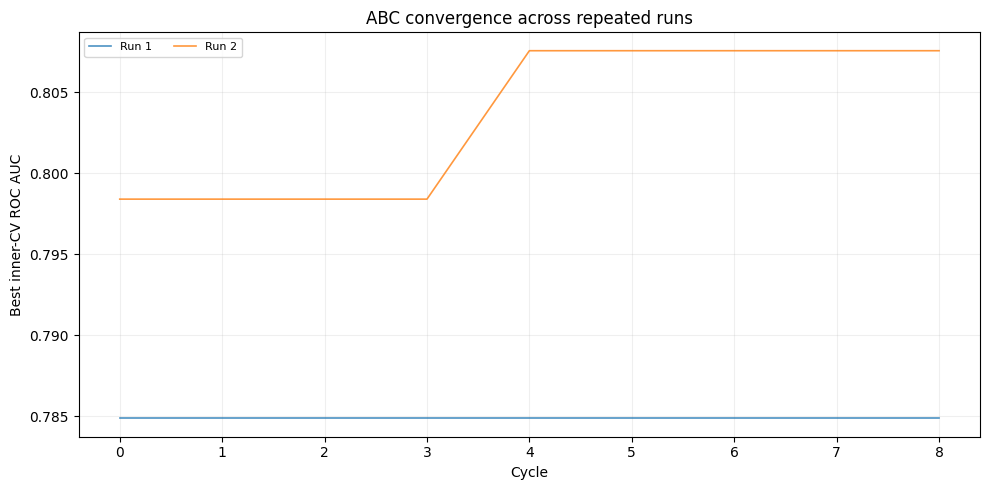

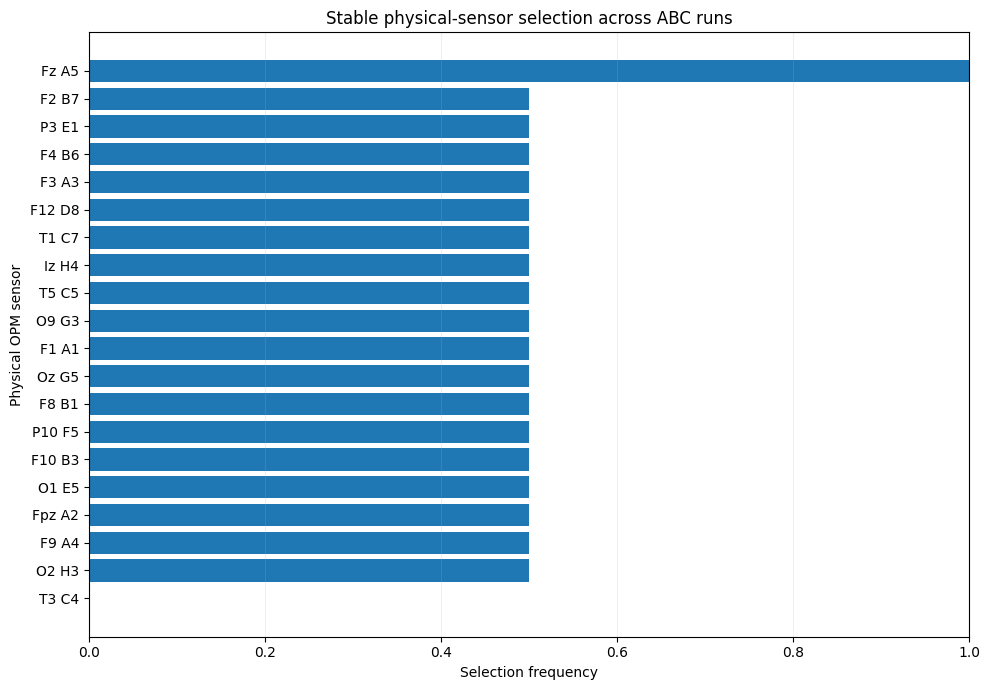

Saved: /kaggle/working/flux_abc/figures/abc_convergence.png
Saved: /kaggle/working/flux_abc/figures/abc_sensor_selection_stability.png


In [16]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for run_index, one_run in convergence_df.groupby(
    "run"
):
    ax.plot(
        one_run["cycle"],
        one_run["best_auc"],
        linewidth=1.2,
        alpha=0.8,
        label=f"Run {run_index}",
    )

ax.set(
    title=(
        "ABC convergence "
        "across repeated runs"
    ),
    xlabel="Cycle",
    ylabel=(
        "Best inner-CV ROC AUC"
    ),
)

ax.grid(
    alpha=0.2
)

if ABC_RUNS <= 10:
    ax.legend(
        fontsize=8,
        ncol=2,
    )

fig.tight_layout()

convergence_figure = (
    FIGURE_ROOT
    / "abc_convergence.png"
)

fig.savefig(
    convergence_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

top_plot_df = (
    consensus_ranking_df.head(
        min(
            20,
            len(
                consensus_ranking_df
            ),
        )
    )
    .sort_values(
        "selection_frequency"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    top_plot_df[
        "physical_sensor"
    ],
    top_plot_df[
        "selection_frequency"
    ],
)

ax.set(
    title=(
        "Stable physical-sensor "
        "selection across ABC runs"
    ),
    xlabel=(
        "Selection frequency"
    ),
    ylabel=(
        "Physical OPM sensor"
    ),
    xlim=(0, 1),
)

ax.grid(
    axis="x",
    alpha=0.2,
)

fig.tight_layout()

stability_figure = (
    FIGURE_ROOT
    / "abc_sensor_selection_stability.png"
)

fig.savefig(
    stability_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(
    "Saved:",
    convergence_figure,
)
print(
    "Saved:",
    stability_figure,
)

In [17]:
comparison_cv = (
    RepeatedStratifiedKFold(
        n_splits=min(
            CONSENSUS_CV_SPLITS,
            int(
                np.min(
                    np.bincount(y)
                )
            ),
        ),
        n_repeats=(
            CONSENSUS_CV_REPEATS
        ),
        random_state=(
            RANDOM_STATE
        ),
    )
)

comparison_splits = list(
    comparison_cv.split(
        X_features,
        y,
    )
)

consensus_columns = (
    subset_columns(
        consensus_sensor_subset,
        sensor_feature_columns,
    )
)

all_columns = subset_columns(
    tuple(
        retained_sensor_names
    ),
    sensor_feature_columns,
)

consensus_scores = (
    cross_val_score(
        make_classifier(),
        X_features[
            :,
            consensus_columns,
        ],
        y,
        cv=comparison_splits,
        scoring="roc_auc",
        n_jobs=(
            OUTER_N_JOBS
        ),
    )
)

all_sensor_scores = (
    cross_val_score(
        make_classifier(),
        X_features[
            :,
            all_columns,
        ],
        y,
        cv=comparison_splits,
        scoring="roc_auc",
        n_jobs=(
            OUTER_N_JOBS
        ),
    )
)

rng = np.random.default_rng(
    RANDOM_STATE + 9000
)

random_subset_means = []

for _ in range(
    RANDOM_BASELINE_REPEATS
):
    random_subset = tuple(
        sorted(
            rng.choice(
                retained_sensor_names,
                size=(
                    TARGET_SENSOR_COUNT
                ),
                replace=False,
            ).tolist()
        )
    )

    random_columns = (
        subset_columns(
            random_subset,
            sensor_feature_columns,
        )
    )

    random_scores = (
        cross_val_score(
            make_classifier(),
            X_features[
                :,
                random_columns,
            ],
            y,
            cv=comparison_splits,
            scoring="roc_auc",
            n_jobs=(
                OUTER_N_JOBS
            ),
        )
    )

    random_subset_means.append(
        float(
            np.mean(
                random_scores
            )
        )
    )

comparison_df = pd.DataFrame(
    [
        {
            "sensor_set": (
                "ABC consensus"
            ),
            "n_physical_sensors": (
                len(
                    consensus_sensor_subset
                )
            ),
            "mean_auc": float(
                np.mean(
                    consensus_scores
                )
            ),
            "std_auc": float(
                np.std(
                    consensus_scores
                )
            ),
            "interpretation": (
                "exploratory_full_data_selection"
            ),
        },
        {
            "sensor_set": (
                "All physical sensors"
            ),
            "n_physical_sensors": (
                len(
                    retained_sensor_names
                )
            ),
            "mean_auc": float(
                np.mean(
                    all_sensor_scores
                )
            ),
            "std_auc": float(
                np.std(
                    all_sensor_scores
                )
            ),
            "interpretation": (
                "baseline"
            ),
        },
        {
            "sensor_set": (
                "Random subsets"
            ),
            "n_physical_sensors": (
                TARGET_SENSOR_COUNT
            ),
            "mean_auc": float(
                np.mean(
                    random_subset_means
                )
            ),
            "std_auc": float(
                np.std(
                    random_subset_means
                )
            ),
            "interpretation": (
                "random_subset_baseline"
            ),
        },
    ]
)

display(comparison_df)

comparison_df.to_csv(
    REPORT_ROOT
    / "exploratory_abc_comparison.csv",
    index=False,
)

pd.DataFrame(
    {
        "random_subset_repeat": np.arange(
            1,
            len(
                random_subset_means
            ) + 1,
        ),
        "mean_auc": (
            random_subset_means
        ),
    }
).to_csv(
    REPORT_ROOT
    / "random_subset_baseline.csv",
    index=False,
)

,sensor_set,n_physical_sensors,mean_auc,std_auc,interpretation
0,ABC consensus,10,0.744375,0.115404,exploratory_full_data_selection
1,All physical sensors,62,0.624375,0.131731,baseline
2,Random subsets,10,0.598604,0.043405,random_subset_baseline


In [18]:
nested_fold_rows = []
nested_prediction_rows = []
nested_selection_counter = Counter()

if RUN_NESTED_CV:
    effective_outer_splits = min(
        OUTER_SPLITS,
        int(
            np.min(
                np.bincount(y)
            )
        ),
    )

    outer_cv = StratifiedKFold(
        n_splits=(
            effective_outer_splits
        ),
        shuffle=True,
        random_state=(
            RANDOM_STATE
        ),
    )

    for fold_index, (
        train_indices,
        test_indices,
    ) in enumerate(
        outer_cv.split(
            X_features,
            y,
        ),
        start=1,
    ):
        print(
            f"Nested outer fold "
            f"{fold_index}/"
            f"{effective_outer_splits}"
        )

        X_train = X_features[
            train_indices
        ]
        y_train = y[
            train_indices
        ]
        X_test = X_features[
            test_indices
        ]
        y_test = y[
            test_indices
        ]

        fold_heuristic, _ = (
            compute_sensor_heuristics(
                X_train,
                y_train,
                retained_sensor_names,
                sensor_feature_columns,
                INNER_SPLITS,
                RANDOM_STATE
                + 1000
                + fold_index,
            )
        )

        fold_redundancy = (
            compute_sensor_redundancy(
                X_train,
                retained_sensor_names,
                sensor_feature_columns,
            )
        )

        fold_result = run_abc(
            X=X_train,
            y_values=y_train,
            sensor_names=(
                retained_sensor_names
            ),
            sensor_columns=(
                sensor_feature_columns
            ),
            heuristic=(
                fold_heuristic
            ),
            redundancy_matrix=(
                fold_redundancy
            ),
            subset_size=(
                TARGET_SENSOR_COUNT
            ),
            food_sources=(
                ABC_FOOD_SOURCES
            ),
            cycles=ABC_CYCLES,
            abandonment_limit=(
                ABC_ABANDONMENT_LIMIT
            ),
            inner_splits=(
                INNER_SPLITS
            ),
            seed=(
                RANDOM_STATE
                + 2000
                + fold_index
            ),
        )

        nested_selection_counter.update(
            fold_result.best_subset
        )

        fold_columns = subset_columns(
            fold_result.best_subset,
            sensor_feature_columns,
        )

        fold_model = (
            make_classifier()
        )

        fold_model.fit(
            X_train[
                :,
                fold_columns,
            ],
            y_train,
        )

        decision_scores = (
            fold_model.decision_function(
                X_test[
                    :,
                    fold_columns,
                ]
            )
        )

        predictions = (
            decision_scores
            >= 0.0
        ).astype(int)

        fold_auc = roc_auc_score(
            y_test,
            decision_scores,
        )

        nested_fold_rows.append(
            {
                "outer_fold": (
                    fold_index
                ),
                "test_auc": float(
                    fold_auc
                ),
                "test_accuracy": float(
                    accuracy_score(
                        y_test,
                        predictions,
                    )
                ),
                "test_balanced_accuracy": float(
                    balanced_accuracy_score(
                        y_test,
                        predictions,
                    )
                ),
                "inner_best_auc": float(
                    fold_result.best_auc
                ),
                "scout_events": int(
                    fold_result.scout_events
                ),
                "selected_sensors": "|".join(
                    fold_result.best_subset
                ),
                "n_train": len(
                    train_indices
                ),
                "n_test": len(
                    test_indices
                ),
            }
        )

        for local_index, global_index in enumerate(
            test_indices
        ):
            nested_prediction_rows.append(
                {
                    "outer_fold": (
                        fold_index
                    ),
                    "global_trial_index": int(
                        global_index
                    ),
                    "true_label": int(
                        y_test[
                            local_index
                        ]
                    ),
                    "decision_score": float(
                        decision_scores[
                            local_index
                        ]
                    ),
                    "predicted_label": int(
                        predictions[
                            local_index
                        ]
                    ),
                }
            )

        print(
            "  held-out AUC:",
            f"{fold_auc:.4f}",
        )
        print(
            "  sensors:",
            fold_result.best_subset,
        )

    nested_fold_df = pd.DataFrame(
        nested_fold_rows
    )

    nested_prediction_df = (
        pd.DataFrame(
            nested_prediction_rows
        )
        .sort_values(
            "global_trial_index"
        )
    )

    nested_summary_df = pd.DataFrame(
        [
            {
                "outer_folds": (
                    effective_outer_splits
                ),
                "mean_fold_auc": float(
                    nested_fold_df[
                        "test_auc"
                    ].mean()
                ),
                "std_fold_auc": float(
                    nested_fold_df[
                        "test_auc"
                    ].std(
                        ddof=1
                    )
                    if len(
                        nested_fold_df
                    ) > 1
                    else 0.0
                ),
                "pooled_oof_auc": float(
                    roc_auc_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "decision_score"
                        ],
                    )
                ),
                "pooled_oof_accuracy": float(
                    accuracy_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "predicted_label"
                        ],
                    )
                ),
                "pooled_oof_balanced_accuracy": float(
                    balanced_accuracy_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "predicted_label"
                        ],
                    )
                ),
                "target_sensor_count": (
                    TARGET_SENSOR_COUNT
                ),
            }
        ]
    )

    display(
        nested_fold_df
    )
    display(
        nested_summary_df
    )

    nested_fold_df.to_csv(
        REPORT_ROOT
        / "nested_cv_folds.csv",
        index=False,
    )

    nested_prediction_df.to_csv(
        REPORT_ROOT
        / "nested_cv_oof_predictions.csv",
        index=False,
    )

    nested_summary_df.to_csv(
        REPORT_ROOT
        / "nested_cv_summary.csv",
        index=False,
    )

    nested_stability_df = (
        pd.DataFrame(
            [
                {
                    "physical_sensor": (
                        sensor_name
                    ),
                    "outer_fold_selection_count": int(
                        nested_selection_counter[
                            sensor_name
                        ]
                    ),
                    "outer_fold_selection_frequency": float(
                        nested_selection_counter[
                            sensor_name
                        ]
                        / effective_outer_splits
                    ),
                }
                for sensor_name
                in retained_sensor_names
            ]
        )
        .sort_values(
            "outer_fold_selection_count",
            ascending=False,
        )
    )

    nested_stability_df.to_csv(
        REPORT_ROOT
        / "nested_cv_sensor_stability.csv",
        index=False,
    )

else:
    nested_fold_df = pd.DataFrame()
    nested_prediction_df = pd.DataFrame()
    nested_summary_df = pd.DataFrame()
    nested_stability_df = pd.DataFrame()

    print(
        "Nested cross-validation "
        "is disabled."
    )

Nested outer fold 1/3
  held-out AUC: 0.5549
  sensors: ('C5 C1', 'C8 F7', 'Cz E2', 'F2 B7', 'F8 B1', 'Iz H4', 'Oz G5', 'P11 E6', 'P7 E7', 'T1 C7')
Nested outer fold 2/3
  held-out AUC: 0.6923
  sensors: ('C5 C1', 'Cz E2', 'F3 A3', 'F9 A4', 'O2 H3', 'O3 G6', 'O6 H1', 'O9 G3', 'P12 F4', 'Pz F8')
Nested outer fold 3/3
  held-out AUC: 0.5976
  sensors: ('C8 F7', 'Cz E2', 'F11 A8', 'F7 C3', 'F8 B1', 'FCz F6', 'O1 E5', 'P12 F4', 'P7 E7', 'T5 C5')


,outer_fold,test_auc,test_accuracy,test_balanced_accuracy,inner_best_auc,scout_events,selected_sensors,n_train,n_test
0,1,0.554945,0.592593,0.593407,0.779835,6,C5 C1|C8 F7|Cz E2|F2 B7|F8 B1|Iz H4|Oz G5|P11 ...,53,27
1,2,0.692308,0.555556,0.549451,0.604424,6,C5 C1|Cz E2|F3 A3|F9 A4|O2 H3|O3 G6|O6 H1|O9 G...,53,27
2,3,0.597633,0.500000,0.500000,0.761317,7,C8 F7|Cz E2|F11 A8|F7 C3|F8 B1|FCz F6|O1 E5|P1...,54,26


,outer_folds,mean_fold_auc,std_fold_auc,pooled_oof_auc,pooled_oof_accuracy,pooled_oof_balanced_accuracy,target_sensor_count
0,3,0.614962,0.070302,0.619375,0.55,0.55,10


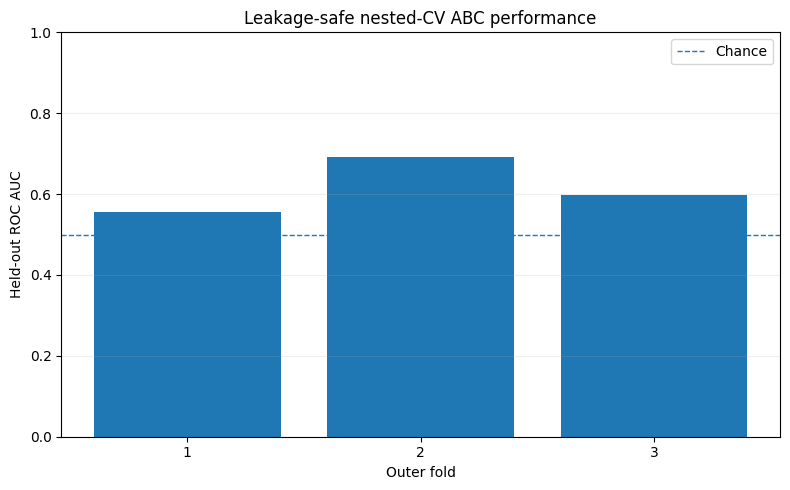

Saved: /kaggle/working/flux_abc/figures/nested_cv_fold_auc.png


In [19]:
if not nested_fold_df.empty:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.bar(
        nested_fold_df[
            "outer_fold"
        ].astype(str),
        nested_fold_df[
            "test_auc"
        ],
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
        label="Chance",
    )

    ax.set(
        title=(
            "Leakage-safe nested-CV "
            "ABC performance"
        ),
        xlabel="Outer fold",
        ylabel=(
            "Held-out ROC AUC"
        ),
        ylim=(0, 1),
    )

    ax.grid(
        axis="y",
        alpha=0.2,
    )
    ax.legend()

    fig.tight_layout()

    nested_figure = (
        FIGURE_ROOT
        / "nested_cv_fold_auc.png"
    )

    fig.savefig(
        nested_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(
        "Saved:",
        nested_figure,
    )

In [20]:
sensor_count_rows = []

if RUN_SENSOR_COUNT_CURVE:
    valid_counts = [
        count
        for count
        in SENSOR_COUNTS_TO_TEST
        if (
            1
            <= count
            <= len(
                retained_sensor_names
            )
        )
    ]

    for sensor_count in valid_counts:
        print(
            "Sensor count:",
            sensor_count,
        )

        result = run_abc(
            X=X_features,
            y_values=y,
            sensor_names=(
                retained_sensor_names
            ),
            sensor_columns=(
                sensor_feature_columns
            ),
            heuristic=(
                full_heuristic
            ),
            redundancy_matrix=(
                full_redundancy
            ),
            subset_size=(
                sensor_count
            ),
            food_sources=(
                COUNT_CURVE_FOOD_SOURCES
            ),
            cycles=(
                COUNT_CURVE_CYCLES
            ),
            abandonment_limit=(
                ABC_ABANDONMENT_LIMIT
            ),
            inner_splits=(
                INNER_SPLITS
            ),
            seed=(
                RANDOM_STATE
                + 5000
                + sensor_count
            ),
        )

        sensor_count_rows.append(
            {
                "n_physical_sensors": (
                    sensor_count
                ),
                "best_inner_cv_auc": (
                    result.best_auc
                ),
                "best_fitness": (
                    result.best_fitness
                ),
                "mean_redundancy": (
                    result.best_redundancy
                ),
                "selected_sensors": "|".join(
                    result.best_subset
                ),
            }
        )

    sensor_count_df = pd.DataFrame(
        sensor_count_rows
    )

    display(
        sensor_count_df
    )

    sensor_count_df.to_csv(
        REPORT_ROOT
        / "abc_sensor_count_curve.csv",
        index=False,
    )

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.plot(
        sensor_count_df[
            "n_physical_sensors"
        ],
        sensor_count_df[
            "best_inner_cv_auc"
        ],
        marker="o",
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set(
        title=(
            "ABC performance versus "
            "physical-sensor count"
        ),
        xlabel=(
            "Number of physical sensors"
        ),
        ylabel=(
            "Best inner-CV ROC AUC"
        ),
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    count_figure = (
        FIGURE_ROOT
        / "abc_sensor_count_curve.png"
    )

    fig.savefig(
        count_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    sensor_count_df = pd.DataFrame()

    print(
        "Sensor-count curve disabled. "
        "Set RUN_SENSOR_COUNT_CURVE=True."
    )

Sensor-count curve disabled. Set RUN_SENSOR_COUNT_CURVE=True.


Exploratory peak: AUC=0.7500 time=0.981 s


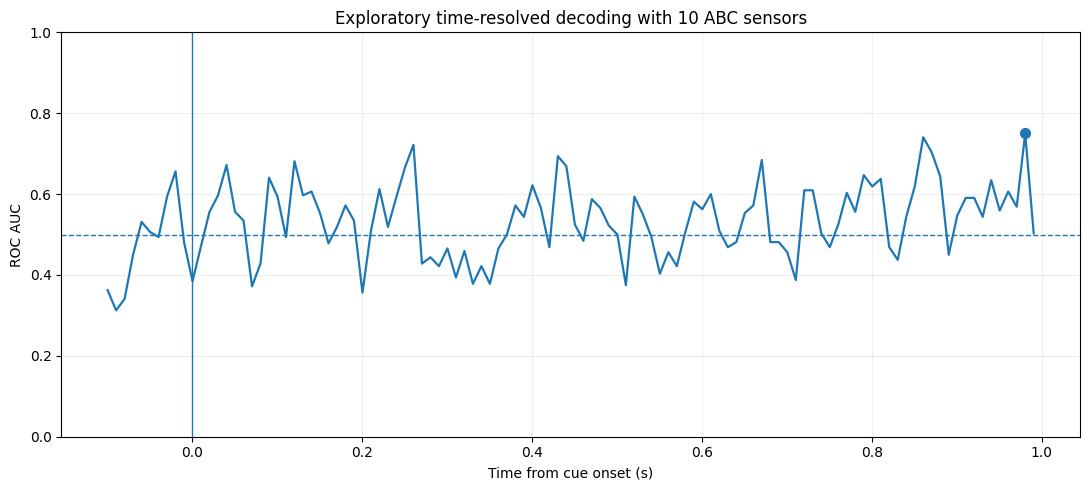

In [21]:
time_resolved_df = pd.DataFrame()

if RUN_TIME_RESOLVED_DECODING:
    consensus_channels = []

    for sensor_name in consensus_sensor_subset:
        consensus_channels.extend(
            [
                channel
                for channel
                in sensor_to_channels[
                    sensor_name
                ]
                if (
                    channel
                    in signal_channel_names
                )
            ]
        )

    channel_indices = [
        signal_channel_names.index(
            channel
        )
        for channel
        in consensus_channels
    ]

    time_mask = (
        (
            signal_times
            >= TIME_DECODING_TMIN_S
        )
        & (
            signal_times
            <= TIME_DECODING_TMAX_S
        )
    )

    decoding_times = (
        signal_times[
            time_mask
        ]
    )

    X_time = X_signal[
        :,
        channel_indices,
        :,
    ][
        :,
        :,
        time_mask,
    ]

    effective_splits = min(
        TIME_DECODING_CV_SPLITS,
        int(
            np.min(
                np.bincount(y)
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=(
            effective_splits
        ),
        shuffle=True,
        random_state=(
            RANDOM_STATE
        ),
    )

    cv_splits = list(
        cv.split(
            X_time,
            y,
        )
    )

    time_auc = []

    for time_index in range(
        X_time.shape[2]
    ):
        scores = cross_val_score(
            make_classifier(),
            X_time[
                :,
                :,
                time_index,
            ],
            y,
            cv=cv_splits,
            scoring="roc_auc",
            n_jobs=(
                INNER_N_JOBS
            ),
        )

        time_auc.append(
            float(
                np.mean(
                    scores
                )
            )
        )

    time_resolved_df = (
        pd.DataFrame(
            {
                "time_s": (
                    decoding_times
                ),
                "mean_auc": (
                    time_auc
                ),
            }
        )
    )

    peak_row = (
        time_resolved_df.iloc[
            int(
                np.argmax(
                    time_resolved_df[
                        "mean_auc"
                    ].to_numpy()
                )
            )
        ]
    )

    print(
        "Exploratory peak:",
        f"AUC={peak_row['mean_auc']:.4f}",
        f"time={peak_row['time_s']:.3f} s",
    )

    time_resolved_df.to_csv(
        REPORT_ROOT
        / "consensus_sensor_time_resolved_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        time_resolved_df[
            "time_s"
        ],
        time_resolved_df[
            "mean_auc"
        ],
        linewidth=1.6,
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axvline(
        0.0,
        linewidth=1.0,
    )

    ax.scatter(
        [
            peak_row[
                "time_s"
            ]
        ],
        [
            peak_row[
                "mean_auc"
            ]
        ],
        s=50,
    )

    ax.set(
        title=(
            f"Exploratory time-resolved "
            f"decoding with "
            f"{TARGET_SENSOR_COUNT} "
            f"ABC sensors"
        ),
        xlabel=(
            "Time from cue onset (s)"
        ),
        ylabel="ROC AUC",
        ylim=(0, 1),
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    time_figure = (
        FIGURE_ROOT
        / "consensus_sensor_time_resolved_auc.png"
    )

    fig.savefig(
        time_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    print(
        "Time-resolved decoding "
        "is disabled."
    )

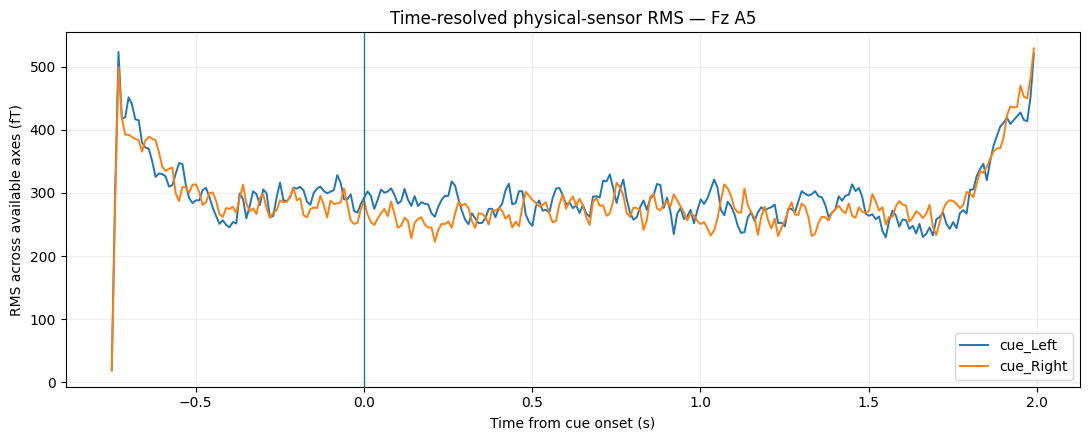

Saved: /kaggle/working/flux_abc/figures/energy_Fz_A5.png


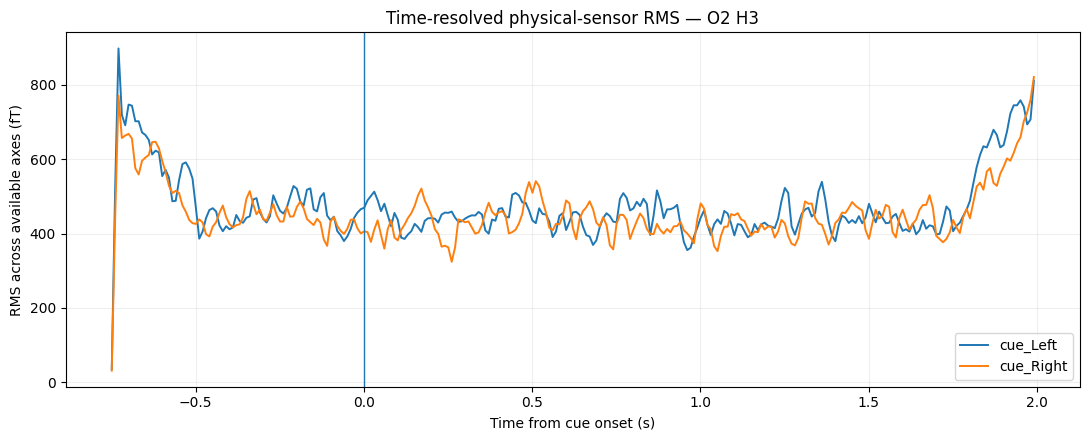

Saved: /kaggle/working/flux_abc/figures/energy_O2_H3.png


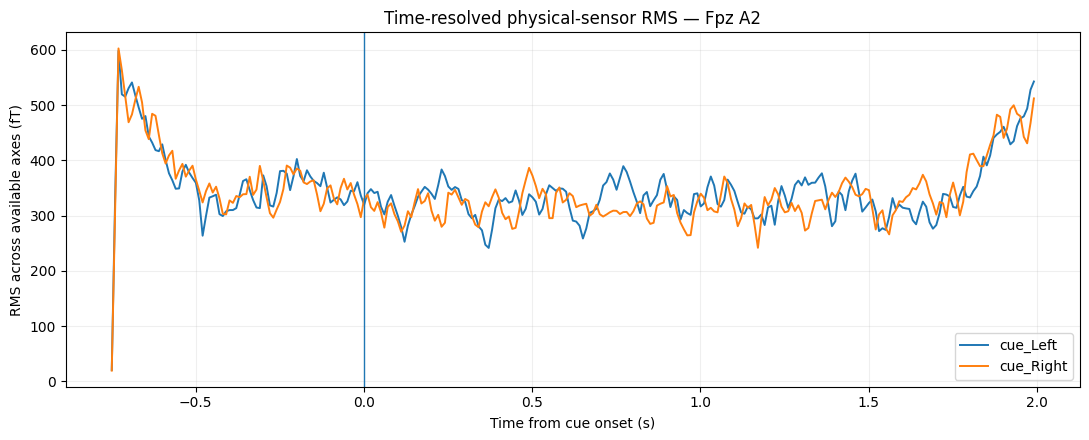

Saved: /kaggle/working/flux_abc/figures/energy_Fpz_A2.png


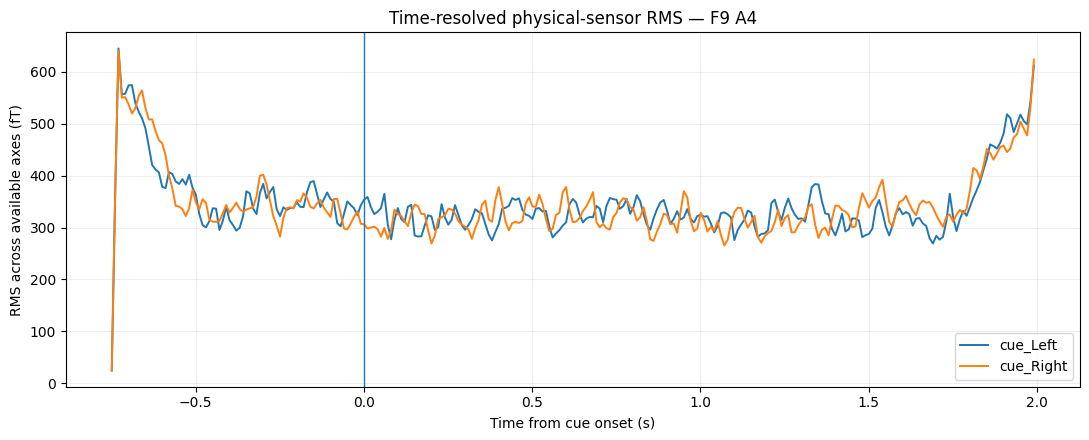

Saved: /kaggle/working/flux_abc/figures/energy_F9_A4.png


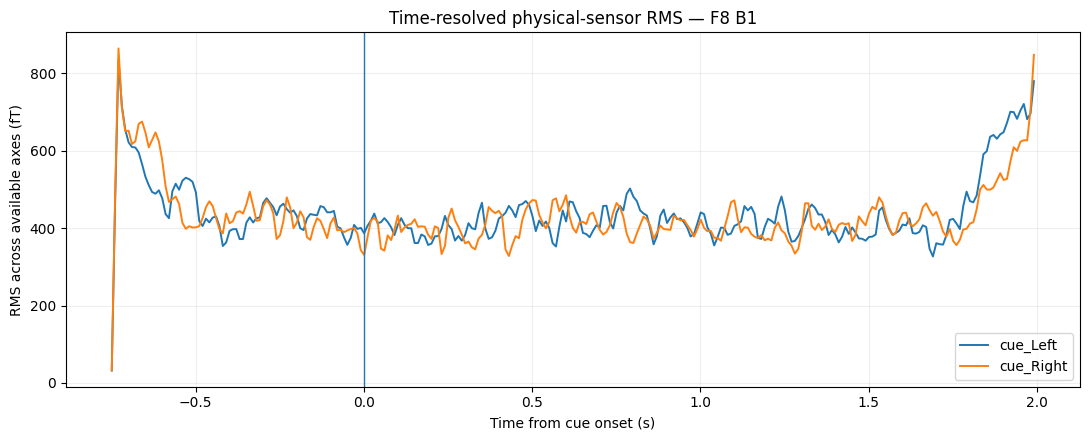

Saved: /kaggle/working/flux_abc/figures/energy_F8_B1.png


In [22]:
leading_sensors = list(
    consensus_sensor_subset[
        :TOP_SENSORS_FOR_ENERGY_PLOTS
    ]
)

for sensor_name in leading_sensors:
    indices = [
        signal_channel_names.index(
            channel
        )
        for channel
        in sensor_to_channels[
            sensor_name
        ]
        if (
            channel
            in signal_channel_names
        )
    ]

    sensor_signal = X_signal[
        :,
        indices,
        :,
    ]

    sensor_energy = np.sqrt(
        np.mean(
            sensor_signal**2,
            axis=1,
        )
    ) * 1e15

    left_mean = np.mean(
        sensor_energy[
            y == 0
        ],
        axis=0,
    )

    right_mean = np.mean(
        sensor_energy[
            y == 1
        ],
        axis=0,
    )

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    ax.plot(
        signal_times,
        left_mean,
        linewidth=1.4,
        label="cue_Left",
    )

    ax.plot(
        signal_times,
        right_mean,
        linewidth=1.4,
        label="cue_Right",
    )

    ax.axvline(
        0.0,
        linewidth=1.0,
    )

    ax.set(
        title=(
            "Time-resolved "
            f"physical-sensor RMS — "
            f"{sensor_name}"
        ),
        xlabel=(
            "Time from cue onset (s)"
        ),
        ylabel=(
            "RMS across available axes "
            "(fT)"
        ),
    )

    ax.grid(
        alpha=0.2
    )
    ax.legend()

    fig.tight_layout()

    safe_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        sensor_name,
    ).strip("_")

    output = (
        FIGURE_ROOT
        / f"energy_{safe_name}.png"
    )

    fig.savefig(
        output,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(
        "Saved:",
        output,
    )

In [23]:
consensus_columns = subset_columns(
    consensus_sensor_subset,
    sensor_feature_columns,
)

final_model = make_classifier()

final_model.fit(
    X_features[
        :,
        consensus_columns,
    ],
    y,
)

model_path = (
    MODEL_ROOT
    / (
        f"sub-{SUBJECT}_ses-{SESSION}_"
        f"task-{TASK}_run-{RUN}_"
        f"desc-abc-"
        f"{TARGET_SENSOR_COUNT}sensor-"
        f"linear-svm.joblib"
    )
)

joblib.dump(
    {
        "model": final_model,
        "physical_sensors": list(
            consensus_sensor_subset
        ),
        "sensor_to_channels": {
            sensor_name: (
                sensor_to_channels[
                    sensor_name
                ]
            )
            for sensor_name
            in consensus_sensor_subset
        },
        "feature_columns": (
            consensus_columns
        ),
        "feature_names": [
            feature_names[index]
            for index
            in consensus_columns
        ],
        "filter_hz": [
            FILTER_L_FREQ_HZ,
            FILTER_H_FREQ_HZ,
        ],
        "resample_hz": (
            RESAMPLE_HZ
        ),
        "feature_window_s": [
            FEATURE_TMIN_S,
            FEATURE_TMAX_S,
        ],
        "n_time_windows": (
            N_TIME_WINDOWS
        ),
        "class_mapping": {
            0: "cue_Left",
            1: "cue_Right",
        },
        "warning": (
            "Model fitted after full-data "
            "exploratory selection. "
            "Use nested-CV metrics for "
            "generalisation reporting."
        ),
    },
    model_path,
)

print(
    "Saved:",
    model_path,
)

Saved: /kaggle/working/flux_abc/models/sub-01_ses-01_task-SpAtt_run-01_desc-abc-10sensor-linear-svm.joblib


In [24]:
nested_text = (
    (
        f"Generalisation was estimated "
        f"with {OUTER_SPLITS}-fold nested "
        "stratified cross-validation, "
        "with the complete ABC search "
        "repeated inside every outer "
        "training fold."
    )
    if RUN_NESTED_CV
    else (
        "Nested cross-validation was "
        "not performed; full-data "
        "selection scores are exploratory."
    )
)

methods_text = (
    "Physical OPM sensors were selected "
    "using a discrete Artificial Bee "
    "Colony algorithm. Available X, Y "
    "and Z channels belonging to the same "
    "physical sensor were retained as one "
    "selectable unit. Cleaned cue-locked "
    f"epochs were filtered from "
    f"{FILTER_L_FREQ_HZ:g} to "
    f"{FILTER_H_FREQ_HZ:g} Hz, resampled "
    f"to {RESAMPLE_HZ:g} Hz, and represented "
    f"with {N_TIME_WINDOWS} windows between "
    f"{FEATURE_TMIN_S:.2f} and "
    f"{FEATURE_TMAX_S:.2f} s after cue onset. "
    "Mean, standard deviation, RMS and pooled "
    "sensor RMS features were extracted. "
    f"Each food source represented exactly "
    f"{TARGET_SENSOR_COUNT} physical sensors. "
    "Employed and onlooker bees explored "
    "one-sensor-swap neighbours, while "
    "stagnant solutions were replaced by "
    "scout bees. Nectar quality was defined "
    "as cross-validated linear-SVM ROC AUC "
    "minus a small inter-sensor redundancy "
    f"penalty. The final search used "
    f"{ABC_FOOD_SOURCES} food sources, "
    f"{ABC_CYCLES} cycles, abandonment limit "
    f"{ABC_ABANDONMENT_LIMIT}, and "
    f"{ABC_RUNS} independent runs for "
    "stability estimation. "
    + nested_text
)

methods_path = (
    REPORT_ROOT
    / "publication_methods.txt"
)

methods_path.write_text(
    methods_text,
    encoding="utf-8",
)

print(
    methods_text
)
print(
    "\nSaved:",
    methods_path,
)

Physical OPM sensors were selected using a discrete Artificial Bee Colony algorithm. Available X, Y and Z channels belonging to the same physical sensor were retained as one selectable unit. Cleaned cue-locked epochs were filtered from 1 to 30 Hz, resampled to 100 Hz, and represented with 8 windows between 0.00 and 0.80 s after cue onset. Mean, standard deviation, RMS and pooled sensor RMS features were extracted. Each food source represented exactly 10 physical sensors. Employed and onlooker bees explored one-sensor-swap neighbours, while stagnant solutions were replaced by scout bees. Nectar quality was defined as cross-validated linear-SVM ROC AUC minus a small inter-sensor redundancy penalty. The final search used 6 food sources, 8 cycles, abandonment limit 4, and 2 independent runs for stability estimation. Generalisation was estimated with 3-fold nested stratified cross-validation, with the complete ABC search repeated inside every outer training fold.

Saved: /kaggle/working/flu

In [25]:
nested_records = (
    []
    if nested_summary_df.empty
    else nested_summary_df.to_dict(
        orient="records"
    )
)

summary = {
    "input_epochs_file": str(
        EPOCHS_FILE
    ),
    "quick_mode": bool(
        QUICK_MODE
    ),
    "class_counts": {
        "cue_Left": int(
            np.sum(y == 0)
        ),
        "cue_Right": int(
            np.sum(y == 1)
        ),
    },
    "physical_sensors": {
        "discovered": int(
            len(
                sensor_inventory_df
            )
        ),
        "retained": int(
            len(
                retained_sensor_names
            )
        ),
        "require_complete_xyz": bool(
            REQUIRE_COMPLETE_XYZ
        ),
    },
    "feature_matrix_shape": list(
        X_features.shape
    ),
    "abc": {
        "target_sensor_count": int(
            TARGET_SENSOR_COUNT
        ),
        "food_sources": int(
            ABC_FOOD_SOURCES
        ),
        "cycles": int(
            ABC_CYCLES
        ),
        "runs": int(
            ABC_RUNS
        ),
        "abandonment_limit": int(
            ABC_ABANDONMENT_LIMIT
        ),
        "redundancy_weight": float(
            REDUNDANCY_WEIGHT
        ),
        "consensus_sensors": list(
            consensus_sensor_subset
        ),
        "mean_run_best_auc": float(
            run_df[
                "best_auc"
            ].mean()
        ),
        "std_run_best_auc": float(
            run_df[
                "best_auc"
            ].std(
                ddof=1
            )
            if len(
                run_df
            ) > 1
            else 0.0
        ),
    },
    "exploratory_comparison": (
        comparison_df.to_dict(
            orient="records"
        )
    ),
    "nested_cv": (
        nested_records
    ),
    "sensor_count_curve_run": bool(
        RUN_SENSOR_COUNT_CURVE
    ),
    "time_resolved_decoding_run": bool(
        RUN_TIME_RESOLVED_DECODING
    ),
    "model_file": str(
        model_path
    ),
    "figures": sorted(
        str(
            path.relative_to(
                WORK_ROOT
            )
        )
        for path in FIGURE_ROOT.glob("*")
        if path.is_file()
    ),
    "reports": sorted(
        str(
            path.relative_to(
                WORK_ROOT
            )
        )
        for path in REPORT_ROOT.glob("*")
        if path.is_file()
    ),
}

summary_path = (
    REPORT_ROOT
    / "abc_sensor_selection_summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

print(
    "Saved:",
    summary_path,
)

Saved: /kaggle/working/flux_abc/reports/abc_sensor_selection_summary.json


In [26]:
figures_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ABC_figures",
    "zip",
    root_dir=FIGURE_ROOT,
)

reports_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ABC_reports",
    "zip",
    root_dir=REPORT_ROOT,
)

models_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ABC_models",
    "zip",
    root_dir=MODEL_ROOT,
)

print(
    "Figures ZIP:",
    figures_zip,
)
print(
    "Reports ZIP:",
    reports_zip,
)
print(
    "Models ZIP:",
    models_zip,
)

Figures ZIP: /kaggle/working/FLUX_ABC_figures.zip
Reports ZIP: /kaggle/working/FLUX_ABC_reports.zip
Models ZIP: /kaggle/working/FLUX_ABC_models.zip
